![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Flux Processing Chain
</b>
</br>
  
</span>
<p>Post-processing of EddyPro <i>_fluxnet_</i> output files</p>

---
**Notebook version**: `9.0` (26 Nov 2024)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

</br>

---

# **BACKGROUND**

---

- This notebook demonstrates part of the flux post-processing used for fluxes from Swiss FluxNet research stations
- For a description of the different flux levels, see [Flux Processing Chain](https://www.swissfluxnet.ethz.ch/index.php/data/ecosystem-fluxes/flux-processing-chain/)
- Flux calculations (Level-1) were done in a previous step
- This notebook uses the calculated fluxes (Level-1) and applies several post-processing steps:
    - Quality flag extension (Level-2)
    - Storage correction (Level-3.1)
    - Outlier removal (Level-3.2)
 
**Important**
- Flux variable names in the input files should follow the [FLUXNET convention](https://fluxnet.org/data/fluxnet2015-dataset/fullset-data-product/)

</br>

</br>

---

# **GENERAL SETTINGS**

---

## Flux variable
`FLUXVAR` is the name of the flux variable in the data files. In the EddyPro `_fluxnet_` output files, the flux variables we primarily use are:
  - `FC` ... CO2 flux, becomes `NEE` after storage correction (Level-3.1)
  - `LE` ... Latent heat flux (water)
  - `H` ... Sensible heat flux
  - `FN2O` ... Nitrous oxide flux
  - `FCH4` ... Methane flux
  
There are more flux variables in the output file, but we rarely need them:
  - `FH2O` ... H2O flux, very important but it is the same as `ET` and `LE` but with different units
  - `ET` ... Evapotranspiration, very important but it is the same as `FH2O` and `LE` but with different units. We can easily calculte `ET` later from `LE`, e.g. in `ReddyProc`.
  - `TAU` ... Momentum flux, a measure of the turbulent transfer of momentum between the land surface and the atmosphere

Set the name of the flux variable in the output file(s), must use the FLUXNET naming convention, e.g. FC, FH2O, LE, ET, H, FN2O, FCH4:

In [1]:
FLUXVAR = "H"

## Site location
- Latitude and longitude of the site where data were recorded. This info is mainly used to calculate potential radiation, which is then used to divide the dataset into daytime and nighttime data.
- UTC offset of the timestamp used in the dataset, important for calculating potential radiation for this location with the correct timestamp.

In [2]:
SITE_LAT = 47.480620
SITE_LON = 8.911868  
UTC_OFFSET = 1  # Time stamp offset in relation to UTC, e.g. 1 for UTC+01:00 (CET), important for the calculation of potential radiation for detecting daytime and nighttime

## Daytime/nighttime
- Threshold for potential radiation in `W m-2`, records below threshold are considered nighttime

In [3]:
NIGHTTIME_THRESHOLD = 20

## Quality requirements
- The default setting is to accept highest-quality and medium-quality fluxes for daytime (overall quality flag `QCF` = 0 or 1), and highest-quality fluxes only for nighttime (flag `QCF` = 0)
- `DAYTIME_ACCEPT_QCF_BELOW = 2` accepts high- (`QCF=0`) and medium-quality (`QCF=1`) fluxes for *daytime*, rejects low-quality (`QCF=2`) fluxes
- `NIGHTTIMETIME_ACCEPT_QCF_BELOW = 1` accepts high-quality (`QCF=0`) fluxes for *nighttime*, rejects medium-quality (`QCF=1`) and low-quality (`QCF=2`) fluxes
- This strict quality-filtering removes a lot of data points during nighttime

In [4]:
DAYTIME_ACCEPT_QCF_BELOW = 2
NIGHTTIMETIME_ACCEPT_QCF_BELOW = 1

</br>

---

# **IMPORTS**

---

- This notebook uses `diive` ([source code](https://github.com/holukas/diive)) to check eddy covariance fluxes for quality

In [5]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats
import seaborn as sns

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.pkgs.flux.hqflux import analyze_highest_quality_flux
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import FluxProcessingChain
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import LoadEddyProOutputFiles

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


</br>

</br>

---

# **DOCSTRING** for `FluxProcessingChain`

---

In [6]:
# help(FluxProcessingChain)

</br>

</br>

---

# **LOAD DATA** (2 options)

---

- It is possible to load data from (multiple) EddyPro _fluxnet_ output files (data from files will be merged), or directly from one single [parquet](https://parquet.apache.org/) file.
- parquet files are a good option for large datasets because they load and save much faster than when using conventional CSV files.
- For large datasets, it makes sense to first load and merge data from the original EddyPro _fluxnet_ output files, then convert the merged data to one single parquet file and then use this file as input file.

</br>

## Option 1: Load data from single or multiple EddyPro *_fluxnet_* output files
- Used to read data from the EddyPro _fluxnet_ output files
- Found files will be merged together into one single dataframe (`maindf`)

If you want to search for EddyPro _fluxnet_ files in specific locations, you can specify multiple folders here:

In [7]:
# # Folder(s) where input file(s) are located
# SOURCEDIRS = [r'example_data/']  

In [8]:
# ep = LoadEddyProOutputFiles(sourcedir=SOURCEDIRS, filetype='EDDYPRO-FLUXNET-CSV-30MIN')
# ep.searchfiles()
# ep.loadfiles()
# maindf = ep.maindf
# metadata = ep.metadata

</br>

## Option 2: Load data from `parquet` file
- Can be used to continue a previous session where another flux variable was already post-processed
- For example, if you have already post-processed CO2 flux and now want to post-process H2O flux
- Also detects time resolution of time series, this info was lost when saving to the parquet file

If you want to load data directly from a specific parquet file, you can specify its name and location here:

In [9]:
SOURCEDIR = r"../../30_MERGE_DATA"
FILENAME = r"33.1_CH-TAN_IRGA+LGR_Level-1_eddypro_fluxnet.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
print(f"Data will be loaded from the following file:\n{FILEPATH}")

Data will be loaded from the following file:
..\..\30_MERGE_DATA\33.1_CH-TAN_IRGA+LGR_Level-1_eddypro_fluxnet.parquet


In [10]:
maindf = load_parquet(filepath=FILEPATH)

Loaded .parquet file ..\..\30_MERGE_DATA\33.1_CH-TAN_IRGA+LGR_Level-1_eddypro_fluxnet.parquet (0.138 seconds).


    --> Detected time resolution of <30 * Minutes> / 30min 


</br>

## Option 3: Load example data

In [11]:
# from diive.configs.exampledata import load_exampledata_EDDYPRO_FLUXNET_CSV_30MIN
# maindf, metadata = load_exampledata_EDDYPRO_FLUXNET_CSV_30MIN()

</br>

## (Optional) Restrict data to time range

In [12]:
# # Restrict data range
# maindf = maindf.loc[(maindf.index.year >= 2008) & (maindf.index.year <= 2010)].copy()

</br>

## Check data

In [13]:
display(maindf.head(3))
display(maindf.tail(3))
display(sstats(maindf[FLUXVAR]))

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2024-08-22 00:15:00,1012.16,1.16533,0.024738,1179.50,0.0,1.0,...,0.000189,0.000093,801000011.0,13215.0,8.038090,7.652170
2024-08-22 00:45:00,1012.11,1.16619,0.024721,1180.31,0.0,1.0,...,-0.001542,-0.004007,800000011.0,4874.0,0.129208,0.124083
2024-08-22 01:15:00,1012.10,1.16655,0.024713,1180.66,0.0,1.0,...,0.003307,0.005093,800000011.0,4637.0,0.097197,0.093010


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,...,0.086701,-0.164623,800000000.0,1.0,0.011462,0.011349
2025-06-04 23:15:00,1014.04,1.14156,0.025222,1157.59,0.0,1.0,...,0.080587,-0.107072,800000000.0,0.0,0.022039,0.021927
2025-06-04 23:45:00,1013.47,1.14369,0.025185,1159.10,0.0,1.0,...,0.065973,-0.135553,800000000.0,4.0,0.020099,0.019992


,H
STARTDATE,2024-08-22 00:15
ENDDATE,2025-06-04 23:45
PERIOD,286 days 23:30:00
NOV,13606
MISSING,170
MISSING_PERC,1.23403
MEAN,7.461694
MEDIAN,-0.699671
SD,54.175809
VAR,2935.018285


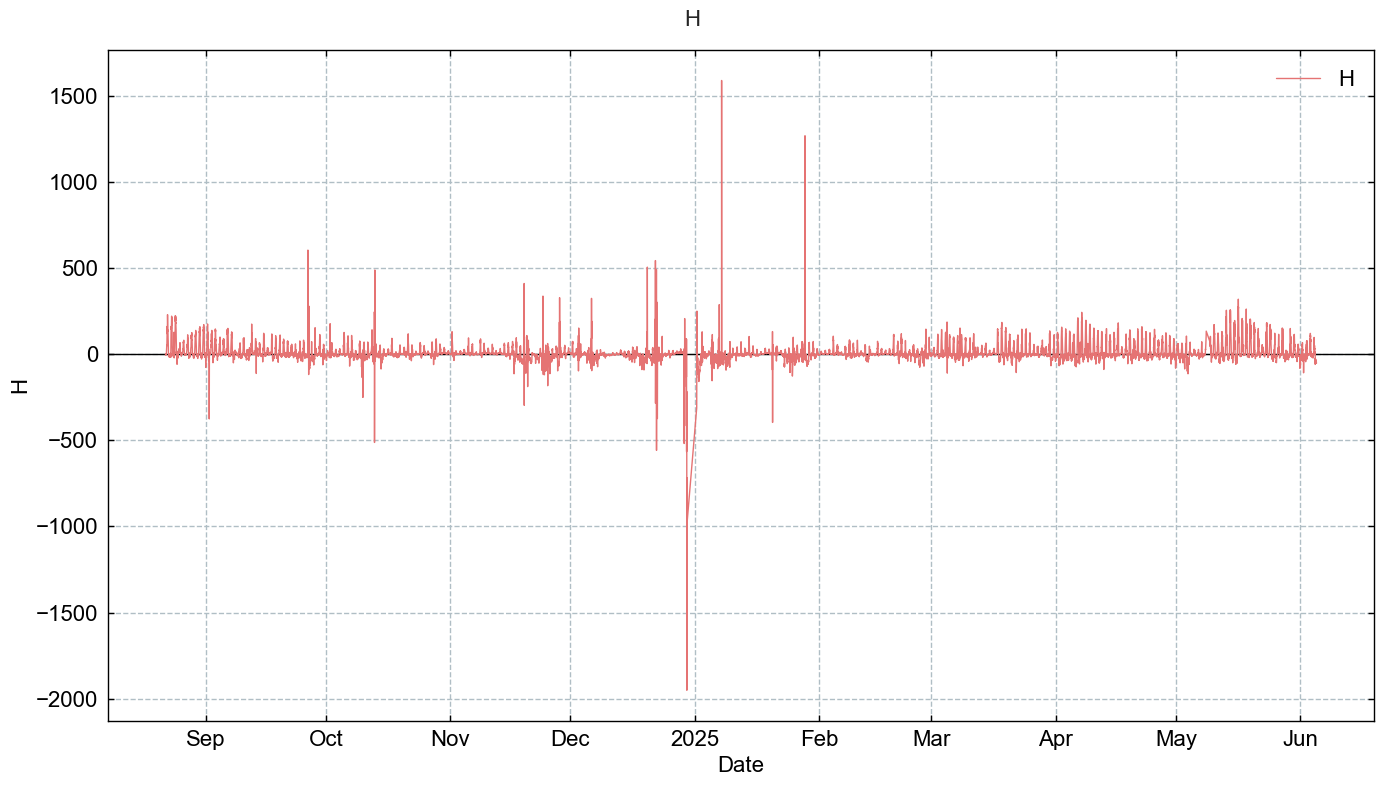

In [14]:
# TimeSeries(series=maindf[FLUXVAR]).plot_interactive()
TimeSeries(series=maindf[FLUXVAR]).plot()

</br>

</br>

---

# **START FLUX PROCESSING CHAIN**

---

- First we need to initialize the processing chain by providing some basic info.
- At the same time, some fundamental variables are also created: potential radiation, and two flags based on it: daytime flag (1=daytime) and nighttime flag (1=nighttime).

In [15]:
fpc = FluxProcessingChain(
    df=maindf,
    fluxcol=FLUXVAR,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=UTC_OFFSET,    
    nighttime_threshold=NIGHTTIME_THRESHOLD,
    daytime_accept_qcf_below=DAYTIME_ACCEPT_QCF_BELOW,
    nighttimetime_accept_qcf_below=NIGHTTIMETIME_ACCEPT_QCF_BELOW
)

Detected base variable T_SONIC for H. (T_SONIC was used to calculate H.)
Calculated potential radiation from latitude and longitude (SW_IN_POT) ... 
Calculated daytime flag DAYTIME and nighttime flag NIGHTTIME from SW_IN_POT ...
++ Added new column SW_IN_POT to input data.  (!) Existing SW_IN_POT in input data is overwritten.
++ Added new column DAYTIME to input data.
++ Added new column NIGHTTIME to input data.


- Let's check the flux processing chain dataframe: this are the data the chain is working with in this run:

In [16]:
fpc.fpc_df

,H,USTAR,SW_IN_POT,DAYTIME,NIGHTTIME
TIMESTAMP_MIDDLE,,,,,
2024-08-22 00:15:00,-0.90021,0.013084,0.0,0.0,1.0
2024-08-22 00:45:00,-2.44523,0.072340,0.0,0.0,1.0
2024-08-22 01:15:00,-2.07966,0.075366,0.0,0.0,1.0
2024-08-22 01:45:00,-4.98663,0.058658,0.0,0.0,1.0
2024-08-22 02:15:00,-2.26875,0.035749,0.0,0.0,1.0
...,...,...,...,...,...
2025-06-04 21:45:00,-37.67390,0.413091,0.0,0.0,1.0
2025-06-04 22:15:00,-33.34900,0.353844,0.0,0.0,1.0
2025-06-04 22:45:00,-39.18460,0.409273,0.0,0.0,1.0


</br>

</br>

---

# Level-2: **QUALITY FLAG EXTENSION**

---

> Extract additional quality information from the EddyPro output and store it in newly added quality flags.



Note that the USTAR filtering is not part of the Level-2 calculations.

</br>

## User settings
- A test for missing values is always included: flag calculated here from missing flux values in the EddyPro output file

</br>

### SSITC tests (default: `True`)
- Flag calculated in EddyPro
- Combination of the two partial tests *steady state test* and *developed turbulent conditions test*
- This notebook expects the SSITC flag to follow the flagging policy according to Mauder and Foken 2004:
    - `0` for best quality fluxes
    - `1` for fluxes suitable for general analysis such as annual budgets (although this is debatable for nighttime data)
    - `2` for fluxes that should be discarded from the dataset

In [17]:
TEST_SSITC = True  # Default True
TEST_SSITC_SETFLAG_TIMEPERIOD = None
# TEST_SSITC_SETFLAG_TIMEPERIOD = {2: [[1, '2022-05-01', '2023-09-30']]}

</br>

### Flux base variable completeness test (default: `True`)
- Flag newly calculated here
- Check completeness of the variable that was used to calculate the respective flux
- Example: `CO2` is the base variable that was used to calculate flux `FC`, the test is therefore run on `CO2`
- Checks number of records of the relevant base variable available for each averaging Interval and calculates completeness flag as follows:
    - `0` for files where >= 99% of base variable are available
    - `1` for files where >= 97% and < 99% of base variable are available
    - `2` for files where < 97% of base variable are available
 
List of flux base variables and the corresponding fluxes:
- `CO2`: used to calculate `FC`
- `H2O`: used to calculate `FH2O`
- `H2O`: used to calculate `LE`
- `H2O`: used to calculate `ET`
- `T_SONIC`: used to calculate `H`
- `N2O`: used to calculate `FN2O`
- `CH4`: used to calculate `FCH4`

In [18]:
TEST_GAS_COMPLETENESS = True  # Default True

</br>

### Spectral correction factor test (default: `True`)
- Flag calculated here from the gas `SCF` variable in EddyPro output file

In [19]:
TEST_SPECTRAL_CORRECTION_FACTOR = True  # Default True

</br>

### Signal strength test

<div class="alert alert-block alert-info">
<b>Always recommended if flux was calculated using a gas analyzer.</b>
</div>  

<div class="alert alert-block alert-danger">
<b>Do not use for H (sensible heat flux).</b> This test is only relevant for fluxes where the concentration/temperature was measured by a gas analyzer, e.g. FC, FH2O, LE, ET, N2O, CH4, etc ... 
</div>  

- Signal strength / AGC / window dirtiness test (if available)
- Flag calculated here from the signal strength / AGC variable for the gas analyzer in EddyPro output file
- `SIGNAL_STRENGTH_COL`: Name of the column storing the signal strength, typically 'CUSTOM_AGC_MEAN' for LI-7500, 'CUSTOM_SIGNAL_STRENGTH_IRGA72_MEAN' for LI-7200, or something similar
- `SIGNAL_STRENGTH_THRESHOLD`: Signal strength threshold, flux values where threshold is exceeded are flagged as rejected
- `SIGNAL_STRENGTH_METHOD`: `discard above` flags fluxes where signal strength > threshold, `discard below` where signal strength < threshold

In [20]:
# Signal strength
TEST_SIGNAL_STRENGTH = False
TEST_SIGNAL_STRENGTH_COL = 'CUSTOM_SIGNAL_STRENGTH_IRGA72_MEAN'  # Typical variable name in fluxnet files
TEST_SIGNAL_STRENGTH_METHOD = 'discard below'
TEST_SIGNAL_STRENGTH_THRESHOLD = 50

In [21]:
# TimeSeries(series=df_orig[SIGNAL_STRENGTH_COL]).plot_interactive()
#TimeSeries(series=maindf[TEST_SIGNAL_STRENGTH_COL]).plot()

</br>

### Raw data screening tests
- Flags were calculated in EddyPro
- See here for more details: [Despiking and raw data statistical screening (EddyPro help)](https://www.licor.com/env/support/EddyPro/topics/despiking-raw-statistical-screening.html)

In [22]:
TEST_RAWDATA = True  # Default True
TEST_RAWDATA_SPIKES = True  # Default True
TEST_RAWDATA_AMPLITUDE = True  # Default True
TEST_RAWDATA_DROPOUT = True  # Default True
TEST_RAWDATA_ABSLIM = False  # Default False
TEST_RAWDATA_SKEWKURT_HF = False  # Default False
TEST_RAWDATA_SKEWKURT_SF = False  # Default False
TEST_RAWDATA_DISCONT_HF = False  # Default False
TEST_RAWDATA_DISCONT_SF = False  # Default False

</br>

### Angle-of-attack test (default: `False`)
> This test calculates sample-wise Angle of Attacks throughout the current flux averaging period, and flags it if the percentage of angles of attack exceeding a user-defined range is beyond a (user-defined) threshold.  
> Source: [EddyPro help](https://www.licor.com/env/support/EddyPro/topics/despiking-raw-statistical-screening.html?Highlight=angle%20of%20attack#Angleofattack)  *(3 Jan 2024)*
- Flag was calculated in EddyPro
- Flag can be useful during some time periods when the sonic anemometer had issues
- Not used by default (similar to ICOS)

In [23]:
TEST_RAWDATA_ANGLE_OF_ATTACK = False  # Default False
TEST_RAWDATA_ANGLE_OF_ATTACK_APPLICATION_DATES = []

</br>

### Steadiness of horizontal wind test (default: `False`)
> This test assesses whether the along-wind and crosswind components of the wind vector undergo a systematic reduction (or increase) throughout the file. If the quadratic combination of such systematic variations is beyond the user-selected limit, the flux averaging period is hard-flagged for instationary horizontal wind (Vickers and Mahrt, 1997, Par. 6g).  
> Source: [EddyPro help](https://www.licor.com/env/support/EddyPro/topics/despiking-raw-statistical-screening.html?Highlight=angle%20of%20attack#Steadinessofhorizontalwind)  *(3 Jan 2024)*
- Flag was calculated in EddyPro

In [24]:
TEST_RAWDATA_STEADINESS_OF_HORIZONTAL_WIND = False  # Default False

</br>

</br>

## Run

In [25]:
LEVEL2_SETTINGS = {
    'signal_strength': {
        'apply': TEST_SIGNAL_STRENGTH,
        'signal_strength_col': TEST_SIGNAL_STRENGTH_COL,
        'method': TEST_SIGNAL_STRENGTH_METHOD,
        'threshold': TEST_SIGNAL_STRENGTH_THRESHOLD},
    'raw_data_screening_vm97': {
        'apply': TEST_RAWDATA,
        'spikes': TEST_RAWDATA_SPIKES,
        'amplitude': TEST_RAWDATA_AMPLITUDE,
        'dropout': TEST_RAWDATA_DROPOUT,
        'abslim': TEST_RAWDATA_ABSLIM,
        'skewkurt_hf': TEST_RAWDATA_SKEWKURT_HF,
        'skewkurt_sf': TEST_RAWDATA_SKEWKURT_SF,
        'discont_hf': TEST_RAWDATA_DISCONT_HF,
        'discont_sf': TEST_RAWDATA_DISCONT_SF},
    'ssitc': {
        'apply': TEST_SSITC,
        'setflag_timeperiod': TEST_SSITC_SETFLAG_TIMEPERIOD},
    'gas_completeness': {
        'apply': TEST_GAS_COMPLETENESS},
    'spectral_correction_factor': {
        'apply': TEST_SPECTRAL_CORRECTION_FACTOR},
    'angle_of_attack': {
        'apply': TEST_RAWDATA_ANGLE_OF_ATTACK,
        'application_dates': TEST_RAWDATA_ANGLE_OF_ATTACK_APPLICATION_DATES},
    'steadiness_of_horizontal_wind': {
        'apply': TEST_RAWDATA_STEADINESS_OF_HORIZONTAL_WIND}
}
fpc.level2_quality_flag_expansion(**LEVEL2_SETTINGS)

[MissingValues]  running MissingValues ...
SSITC TEST: Generated new flag variable FLAG_L2_H_SSITC_TEST, values taken from output variable H_SSITC_TEST ...
FLUX BASE VARIABLE COMPLETENESS TEST: Generated new flag variable FLAG_L2_H_COMPLETENESS_TEST, newly calculated from variable T_SONIC, with flag 0 (good values) where available number of records for T_SONIC >= 0.99, flag 1 (ok values) >= 0.97 and < 0.99, flag 2 (bad values) < 0.97...
SPECTRAL CORRECTION FACTOR TEST: Generating new flag variable FLAG_L2_H_SCF_TEST, newly calculated from output variable H_SCF, withflag 0 (good values) where H_SCF < 2, flag 1 (ok values) where H_SCF >= 2 and < 4, flag 2 (bad values) where H_SCF >= 4...


RAW DATA TEST: Generated new flag variable FLAG_L2_H_T_SONIC_VM97_SPIKE_HF_TEST, values taken from output variable T_SONIC_VM97_TEST from position 1, based on T_SONIC, with flag 0 (good values) where test passed, flag 2 (bad values) where test failed (for hard flags) or flag 1 (ok values) where test failed (for soft flags) ...
RAW DATA TEST: Generated new flag variable FLAG_L2_H_T_SONIC_VM97_AMPLITUDE_RESOLUTION_HF_TEST, values taken from output variable T_SONIC_VM97_TEST from position 2, based on T_SONIC, with flag 0 (good values) where test passed, flag 2 (bad values) where test failed (for hard flags) or flag 1 (ok values) where test failed (for soft flags) ...
RAW DATA TEST: Generated new flag variable FLAG_L2_H_T_SONIC_VM97_DROPOUT_TEST, values taken from output variable T_SONIC_VM97_TEST from position 3, based on T_SONIC, with flag 0 (good values) where test passed, flag 2 (bad values) where test failed (for hard flags) or flag 1 (ok values) where test failed (for soft flags) ...

</br>

</br>

## Finalize Level-2

In [26]:
fpc.finalize_level2()

++Added new column FLAG_L2_H_MISSING_TEST.
++Added new column FLAG_L2_H_SSITC_TEST.
++Added new column FLAG_L2_H_COMPLETENESS_TEST.
++Added new column FLAG_L2_H_SCF_TEST.
++Added new column FLAG_L2_H_T_SONIC_VM97_SPIKE_HF_TEST.
++Added new column FLAG_L2_H_T_SONIC_VM97_AMPLITUDE_RESOLUTION_HF_TEST.
++Added new column FLAG_L2_H_T_SONIC_VM97_DROPOUT_TEST.
++Added new column SUM_L2_H_HARDFLAGS.
++Added new column SUM_L2_H_SOFTFLAGS.
++Added new column SUM_L2_H_FLAGS.
++Added new column FLAG_L2_H_QCF.
++Added new column H_L2_QCF.
++Added new column H_L2_QCF0.


</br>

### Available `Level-2` variables
- This shows all available Level-2 variables for this flux

In [27]:
[x for x in fpc.fpc_df.columns if 'L2' in x]

['FLAG_L2_H_MISSING_TEST',
 'FLAG_L2_H_SSITC_TEST',
 'FLAG_L2_H_COMPLETENESS_TEST',
 'FLAG_L2_H_SCF_TEST',
 'FLAG_L2_H_T_SONIC_VM97_SPIKE_HF_TEST',
 'FLAG_L2_H_T_SONIC_VM97_AMPLITUDE_RESOLUTION_HF_TEST',
 'FLAG_L2_H_T_SONIC_VM97_DROPOUT_TEST',
 'SUM_L2_H_HARDFLAGS',
 'SUM_L2_H_SOFTFLAGS',
 'SUM_L2_H_FLAGS',
 'FLAG_L2_H_QCF',
 'H_L2_QCF',
 'H_L2_QCF0']

</br>

### Plots

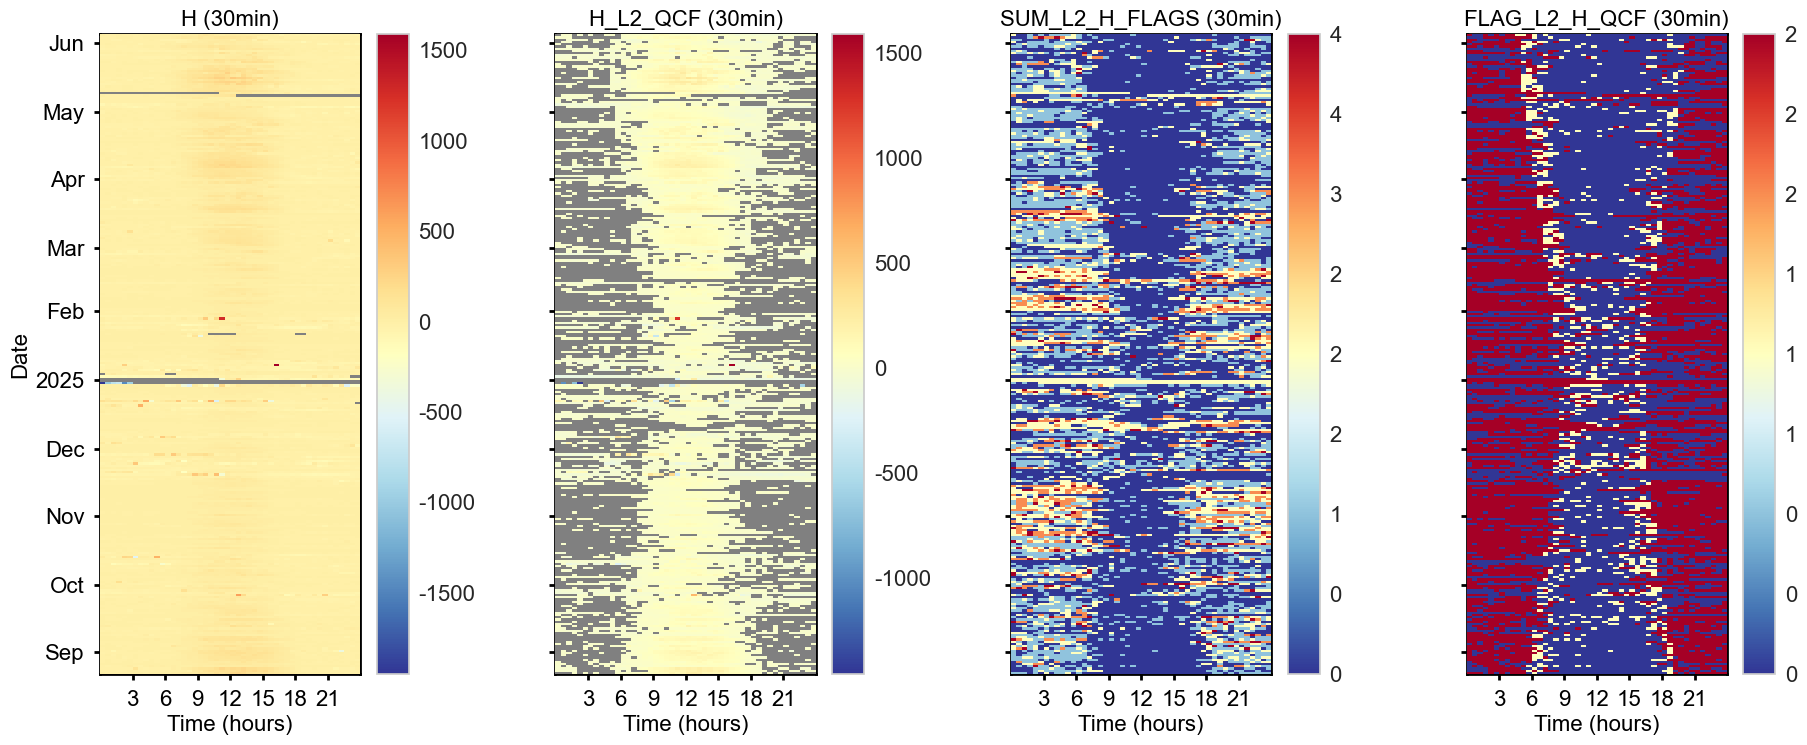

In [28]:
fpc.level2_qcf.showplot_qcf_heatmaps()

In [29]:
# fpc.level2_qcf.showplot_qcf_timeseries()

</br>

### Reports

In [30]:
fpc.level2_qcf.report_qcf_evolution()



QCF FLAG EVOLUTION
This output shows the evolution of the QCF overall quality flag
when test flags are applied sequentially to the variable H.

Number of H records before QC: 13606
+++ FLAG_L2_H_MISSING_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 13606 (100.00%) / flag 1: 0 (0.00%) / flag 2: 0 (0.00%)
+++ FLAG_L2_H_SSITC_TEST rejected 4193 values (+30.82%)      TOTALS: flag 0: 8302 (61.02%) / flag 1: 1111 (8.17%) / flag 2: 4193 (30.82%)
+++ FLAG_L2_H_COMPLETENESS_TEST rejected 3 values (+0.02%)      TOTALS: flag 0: 8299 (61.00%) / flag 1: 1111 (8.17%) / flag 2: 4196 (30.84%)
+++ FLAG_L2_H_SCF_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 8299 (61.00%) / flag 1: 1111 (8.17%) / flag 2: 4196 (30.84%)
+++ FLAG_L2_H_T_SONIC_VM97_SPIKE_HF_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 8299 (61.00%) / flag 1: 1111 (8.17%) / flag 2: 4196 (30.84%)
+++ FLAG_L2_H_T_SONIC_VM97_AMPLITUDE_RESOLUTION_HF_TEST rejected 1396 values (+10.26%)      TOTALS: flag 0: 7094 (52.14%) / f

In [31]:
fpc.level2_qcf.report_qcf_series()



SUMMARY: FLAG_L2_H_QCF, QCF FLAG FOR H
Between 2024-08-22 00:15 and 2025-06-04 23:45 ...
    Total flux records BEFORE quality checks: 13606 (98.77% of potential)
    Available flux records AFTER quality checks: 8014 (58.90% of total)
    Rejected flux records: 5592 (41.10% of total)
    Potential flux records: 13776
    Potential flux records missed: 170 (1.23% of potential)



In [32]:
# fpc.level2_qcf.report_qcf_flags()

</br>

</br>

---

# Level-3.1: **STORAGE CORRECTION**

---

- The flux storage term (single point) is added to the flux
- For some records, the storage term can be missing. In such cases, missing terms are gap-filled using the rolling mean in an expanding window.
- Without gap-filling the storage term, we can lose an additional e.g. 2-3% of flux data

</br>

## Run

In [33]:
fpc.level31_storage_correction(gapfill_storage_term=True)

Detected storage variable SH_SINGLE for H.
Calculating storage-corrected flux H_L3.1 from flux H and storage term SH_SINGLE ...
Missing values for storage term SH_SINGLE_gfRMED_L3.1: 7
Gap-filling storage-term SH_SINGLE with rolling median (window size = 5 records, centered)  |  still missing values for storage term SH_SINGLE_gfRMED_L3.1: 6 ...
Gap-filling storage-term SH_SINGLE with rolling median (window size = 7 records, centered)  |  still missing values for storage term SH_SINGLE_gfRMED_L3.1: 0 ...


</br>

## **Finalize Level-3.1**

In [34]:
fpc.finalize_level31()

++Added new column SH_SINGLE.
++Added new column SH_SINGLE_gfRMED_L3.1.
++Added new column FLAG_SH_SINGLE_gfRMED_L3.1_ISFILLED.
++Added new column H_L3.1.
++Added new column H_L3.1_QCF (Level-3.1 with applied quality flag from Level-2).
++Added new column H_L3.1_QCF0 (Level-3.1 with applied quality flag from Level-2).


</br>

### Available `Level-3.1` variables
- This shows all available Level-3.1 variables for this flux

In [35]:
[x for x in fpc.fpc_df.columns if 'L3.1' in x]

['SH_SINGLE_gfRMED_L3.1',
 'FLAG_SH_SINGLE_gfRMED_L3.1_ISFILLED',
 'H_L3.1',
 'H_L3.1_QCF',
 'H_L3.1_QCF0']

</br>

### Plots

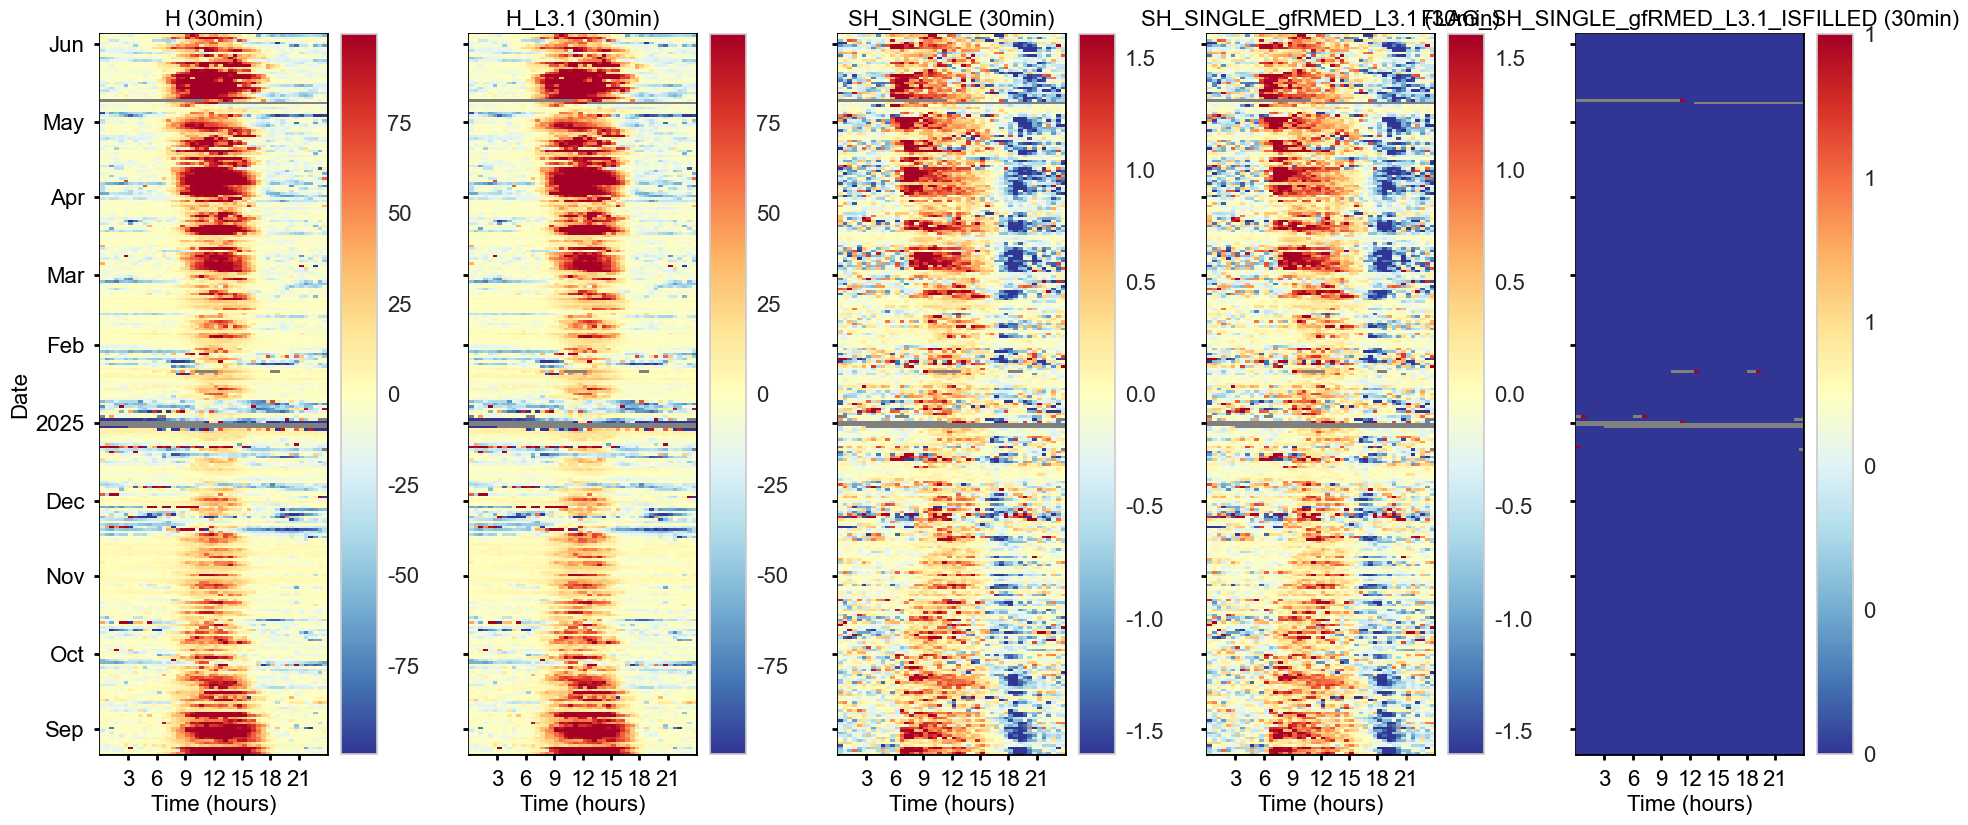

In [36]:
fpc.level31.showplot()

</br>

### Report

In [37]:
fpc.level31.report()


REPORT: STORAGE CORRECTION FOR H
Swiss FluxNet processing chain, _L3.1: Storage Correction

The gap-filled storage term SH_SINGLE_gfRMED_L3.1 was added to flux H.
The storage-corrected flux was stored as H_L3.1.

The flux was available for 13606 records (H).
The original, non-gapfilled storage term was available for 13599 records (SH_SINGLE).
The original storage term SH_SINGLE was missing for 7 flux records.
Without gap-filling the storage term (SH_SINGLE), 7 measured flux records (H) are lost.

For this run, gap-filling of SH_SINGLE was * SELECTED *.
After gap-filling the storage term, it was available for an additional 7 records (SH_SINGLE_gfRMED_L3.1).

In the storage-corrected flux H_L3.1 with 13606 records, 
  - 99.9% (13599 records) of used storage terms come from originally calculated data (SH_SINGLE)
  - 0.1% (7 records) of used storage terms come from gap-filled data (SH_SINGLE_gfRMED_L3.1)

Stats for gap-filled storage terms:
                      NOV       P01    MEDIAN   

</br>

---    

# Optional: **Analyze highest-quality flux** (so far)

---

- Analysis of fluxes after Level-3.1 where the overall quality flag `QCF` = 0
- This helps in understanding in what range the "true" flux occurs
- Here, the highest-quality fluxes are additionally filtered for outlier values using the relatively fast Local Outlier Factor test
- For this quick analysis, it is possible that the outlier test cuts off some "real" values that should be retained, but it nevertheless helps in understanding the flux range
- `QCF` = 0 is best quality, `QCF` = medium quality, `QCF` = 2 bad quality and always rejected
- The difference between quality 0 and quality 1 or 2 is huge


>>> Removing outliers from highest-quality DAYTIME fluxes (H_L3.1_QCF0)
>>> Outlier removal method: Local outlier factor across all data (n_neighbors=22, contamination=auto, repeat=False)
[LocalOutlierFactorAllData]  running LocalOutlierFactorAllData ...
ITERATION#1: Total found outliers: 27 values (daytime+nighttime)


>>> Largest non-outlier flux >= 0 DAYTIME:   255.73004
>>> Smallest non-outlier flux >= 0 DAYTIME:  0.295567
>>> Largest non-outlier flux < 0 DAYTIME:    -0.029179999999999984
>>> Smallest non-outlier flux < 0 DAYTIME:   -73.469149
>>> Largest outlier flux >= 0 DAYTIME:   411.24151
>>> Smallest outlier flux >= 0 DAYTIME:  257.853186
>>> Largest outlier flux < 0 DAYTIME:    -78.35108500000001
>>> Smallest outlier flux < 0 DAYTIME:   -395.78730399999995

>>> Removing outliers from highest-quality NIGHTTIME fluxes (H_L3.1_QCF0)
>>> Outlier removal method: Local outlier factor across all data (n_neighbors=13, contamination=auto, repeat=False)
[LocalOutlierFactorAllData]  running LocalOutlierFactorAllData ...
ITERATION#1: Total found outliers: 46 values (daytime+nighttime)


>>> Largest non-outlier flux >= 0 NIGHTTIME:   129.158947
>>> Smallest non-outlier flux >= 0 NIGHTTIME:  0.452105
>>> Largest non-outlier flux < 0 NIGHTTIME:    -0.05882300000000007
>>> Smallest non-outlier flux < 0 NIGHTTIME:   -131.49627999999998
>>> Largest outlier flux >= 0 NIGHTTIME:   544.17195
>>> Smallest outlier flux >= 0 NIGHTTIME:  14.90776
>>> Largest outlier flux < 0 NIGHTTIME:    -0.21839300000000006
>>> Smallest outlier flux < 0 NIGHTTIME:   -1460.806373


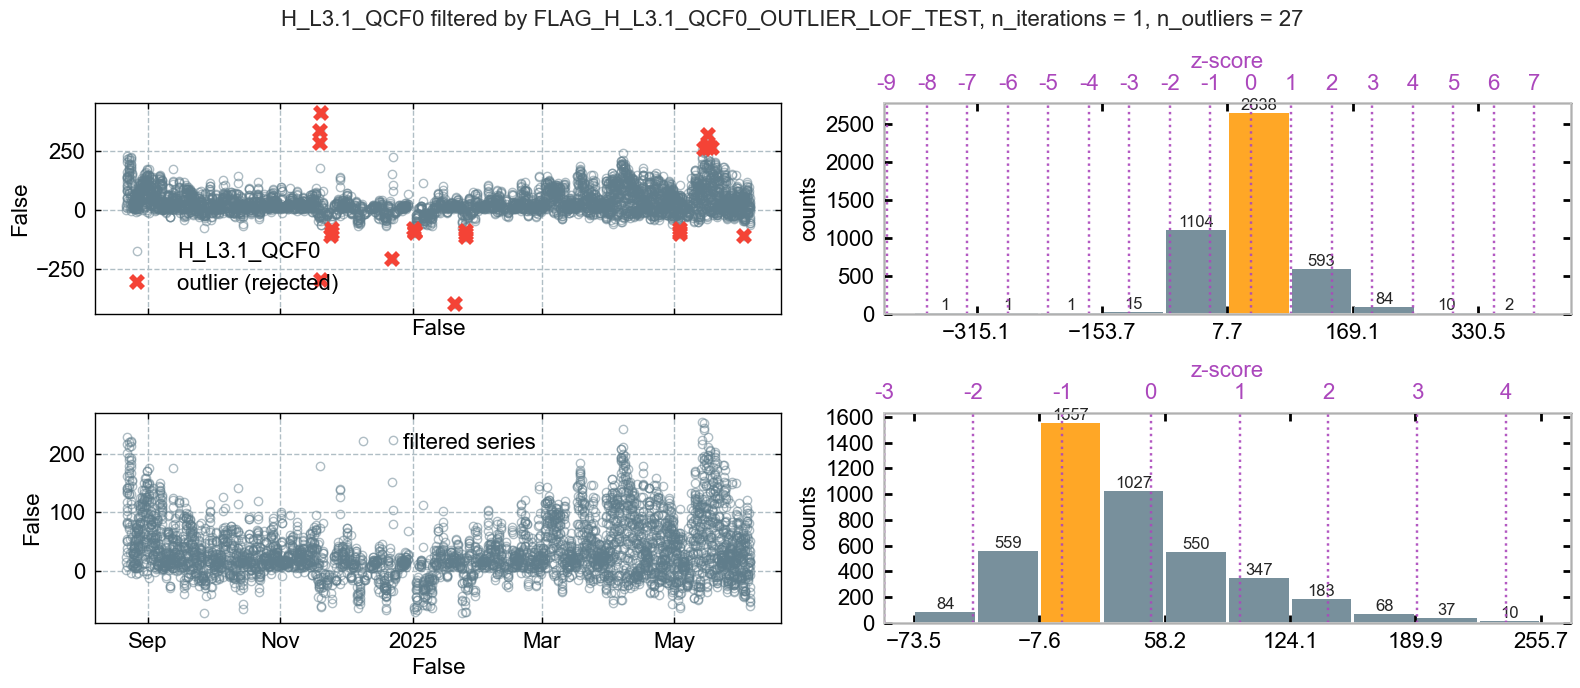

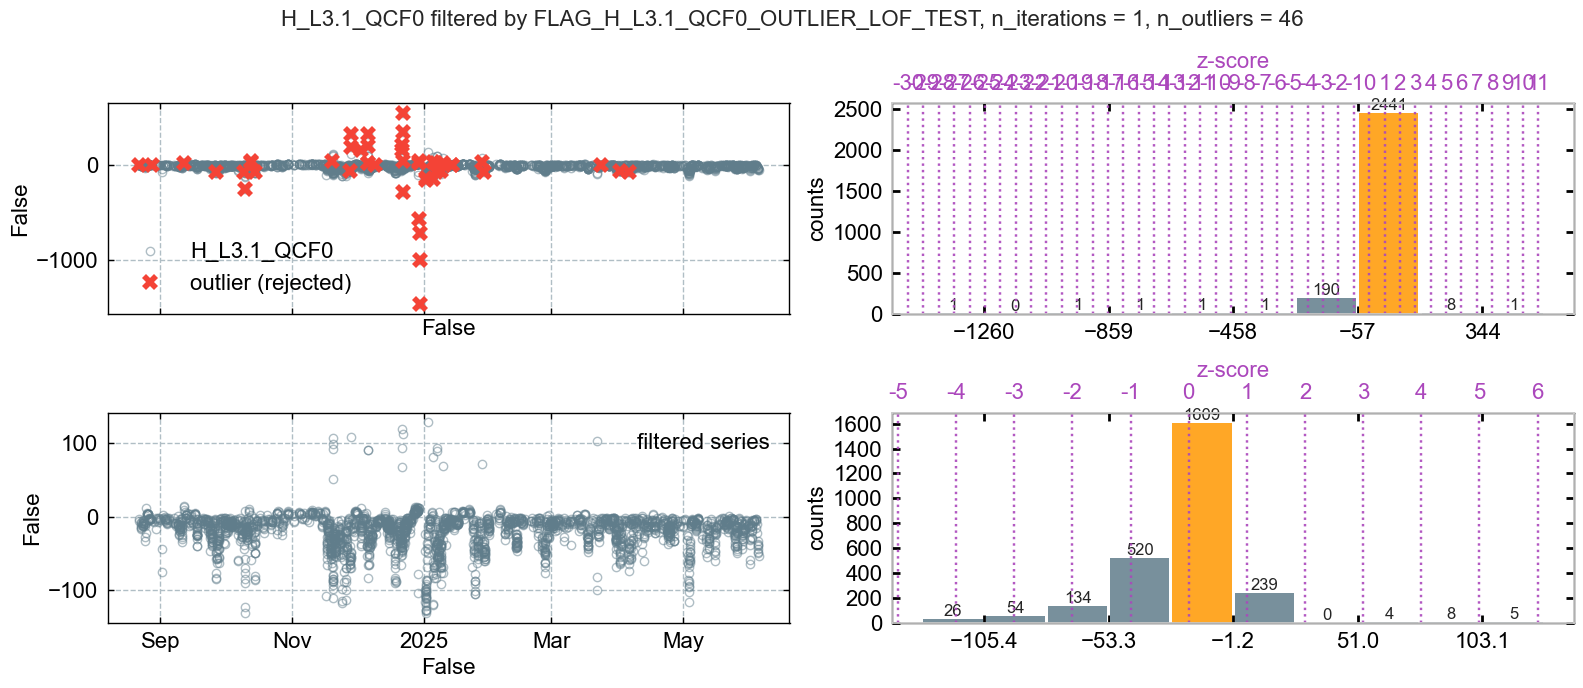

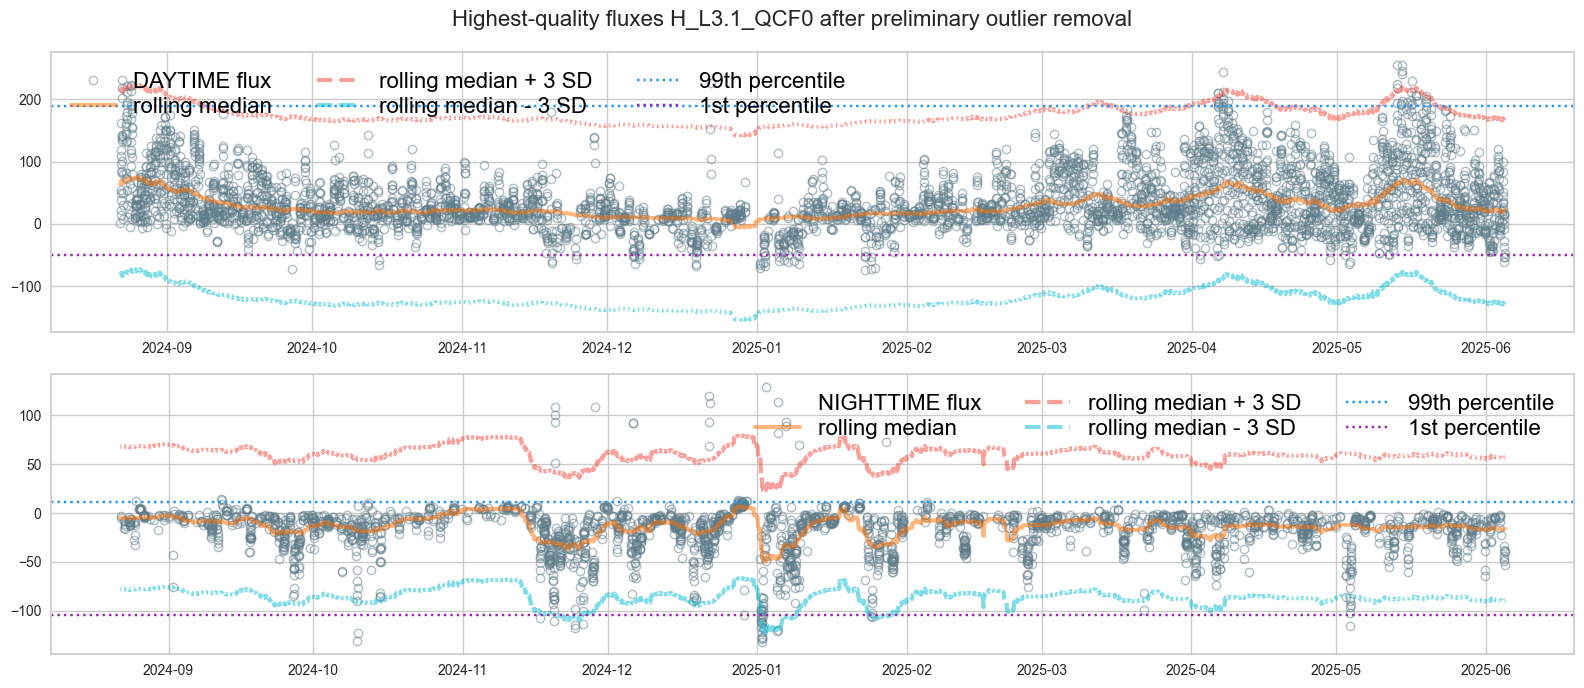

In [38]:
analyze_highest_quality_flux(flux=fpc.fpc_df[fpc.filteredseries_hq.name], nighttime_flag=fpc.fpc_df['NIGHTTIME'])

</br>

</br>

---

# Level-3.2: **OUTLIER DETECTION**

---

- Running an outlier test creates a *preview* plot of the results
- If the output looks as desired, run `fpc.level32_addflag()` cell below the preview to accept the results you see in the plot
- All subsequent tests will then be based on these results
- This means that each test is run on the data already filtered by the previous test
- Each test creates its own quality flag
- At the end of Level-3.2, an overall quality flag `QCF` is created that combines all of the individual flags into one single flag

</br>

## Plot time series

In [39]:
print(f"{fpc.filteredseries.name} \n(quality-controlled Level-3.1 version of {fpc.fluxcol})")

H_L3.1_QCF 
(quality-controlled Level-3.1 version of H)


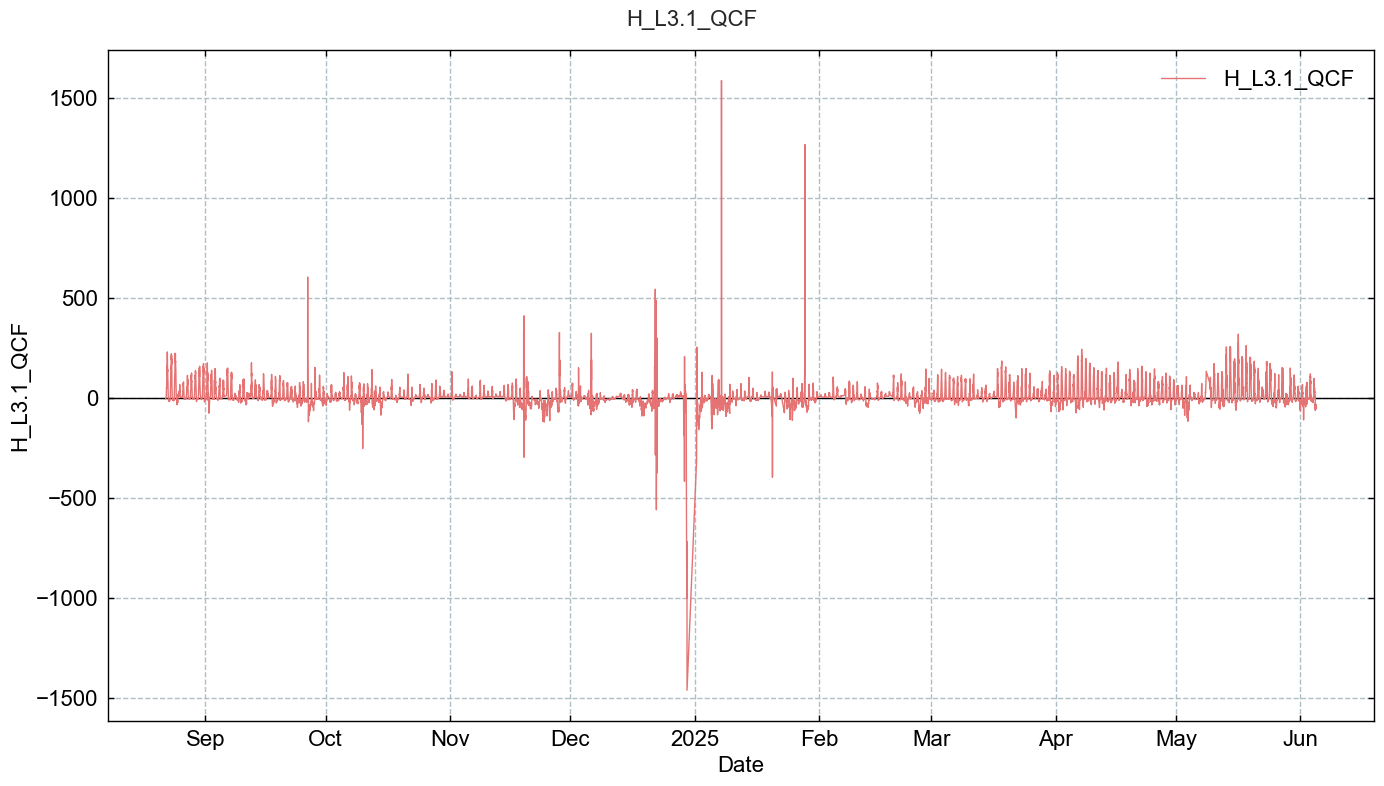

In [40]:
# TimeSeries(series=fpc.fpc_df[fpc.filteredseries.name]).plot_interactive()
TimeSeries(series=fpc.fpc_df[fpc.filteredseries.name]).plot()

</br>

## Initiate calculations

In [41]:
fpc.level32_stepwise_outlier_detection()

</br>

</br>

## Outlier flag: **Absolute limits**
- remove values outside a physically plausible range
- typical value for CO2 flux `FC`: +/-50 µmol m-2 s-1
- typical value for latent evaporation flux `LE`: +800 / -50 W m-2
- typical value for sensible heat flux `H`: +400 / -200 W m-2

In [42]:
# from diive.pkgs.outlierdetection.absolutelimits import AbsoluteLimits
# help(AbsoluteLimits)

[AbsoluteLimits]  running AbsoluteLimits ...


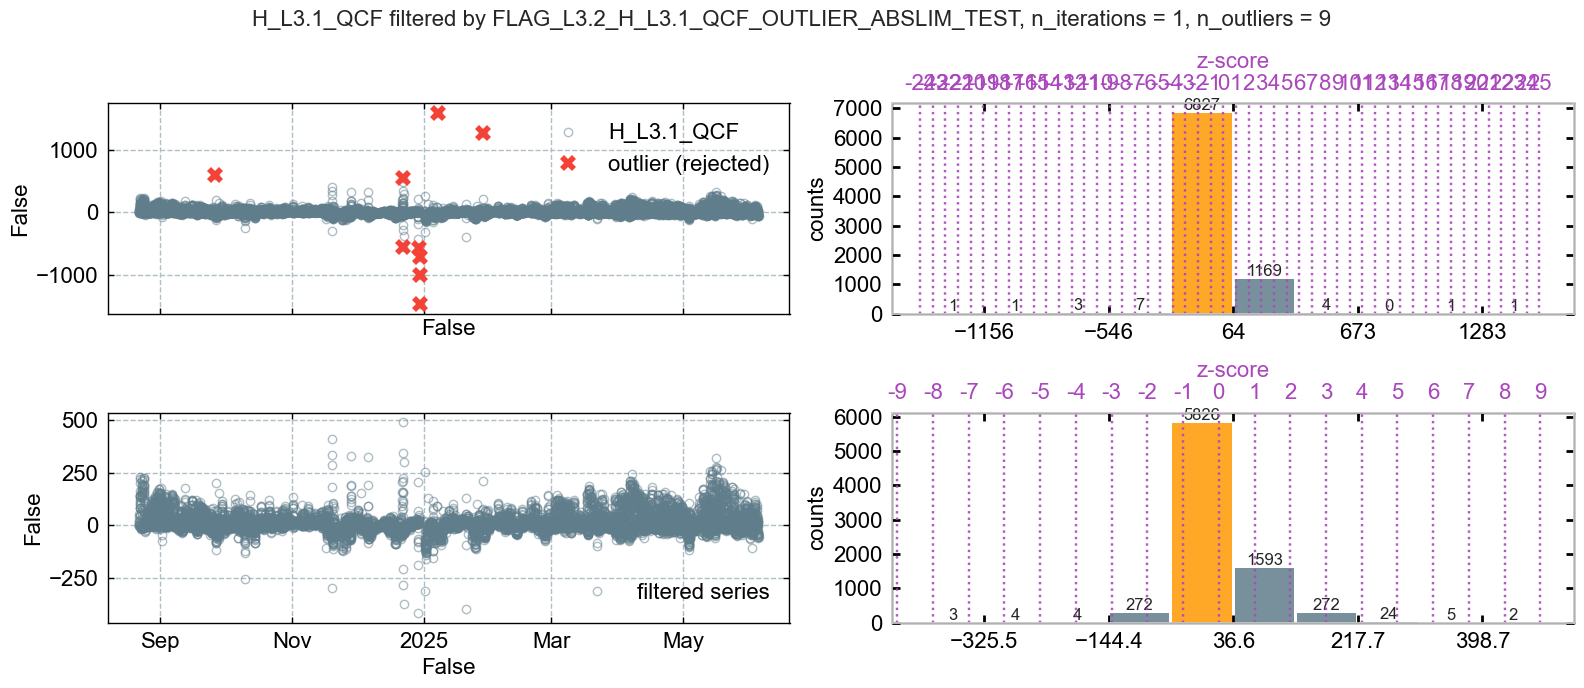

In [43]:
MIN = -500
MAX = 500
fpc.level32_flag_outliers_abslim_test(minval=MIN, maxval=MAX, showplot=True, verbose=True)

In [44]:
fpc.level32_addflag()

++Added flag column FLAG_L3.2_H_L3.1_QCF_OUTLIER_ABSLIM_TEST to flag data


</br>

## Outlier flag: **Manual flag**
- The interactive plot can be used to determine the exact start and end of time ranges or data points that need to be removed, e.g. due to known instrument failure

In [45]:
# from diive.pkgs.outlierdetection.manualremoval import ManualRemoval
# help(ManualRemoval)

In [46]:
# fpc.level32.showplot_cleaned(interactive=True)  # True or False
# fpc.level32.showplot_cleaned(interactive=False)  # True or False

In [47]:
# REMOVE_DATES = [
#     ['2025-04-04', '2025-04-10 15:00:00'],  # Removes date range between two datetimes (inclusive)
#     # '2023-12-12 12:45:00'  # Removes data point with specific timestamp
# ]
# fpc.level32_flag_manualremoval_test(
#     remove_dates=REMOVE_DATES,
#     showplot=True, verbose=True)

In [48]:
#fpc.level32_addflag()

In [49]:
#fpc.level32.showplot_cleaned(interactive=True)  # True or False

</br>

## Outlier flag: High quality based, separate for daytime and nighttime - local standard deviation, with rolling median


Iteration 1
HQRoll detected 100 new outliers.
Outliers this round: 100


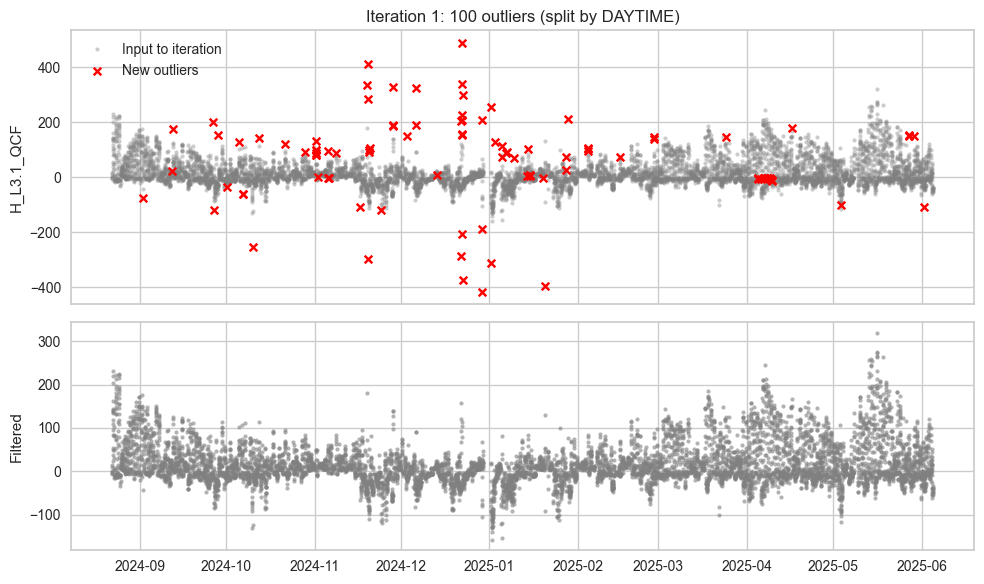


Iteration 2
HQRoll detected 27 new outliers.
Outliers this round: 27


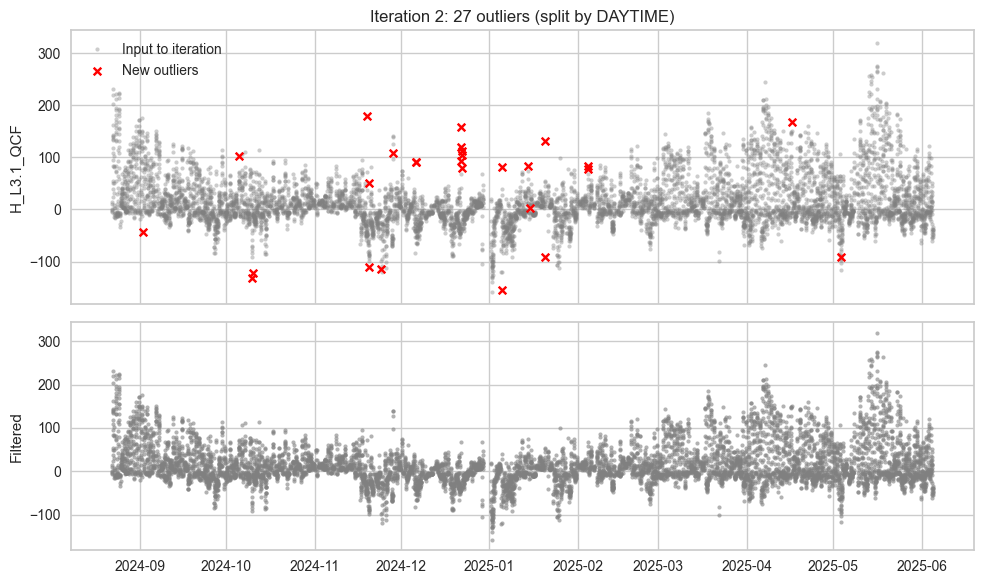


Iteration 3
HQRoll detected 6 new outliers.
Outliers this round: 6


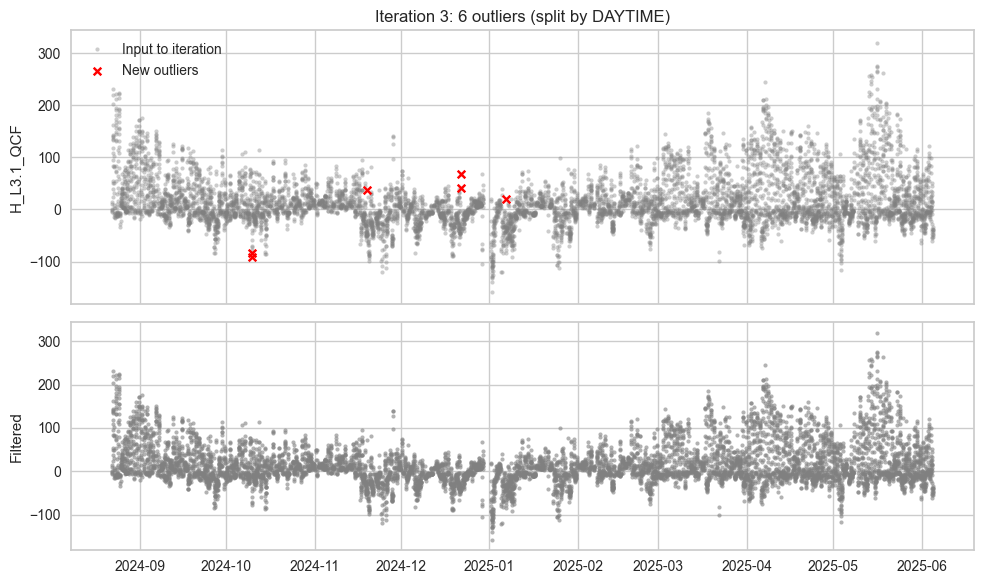


Iteration 4
HQRoll detected 4 new outliers.
Outliers this round: 4


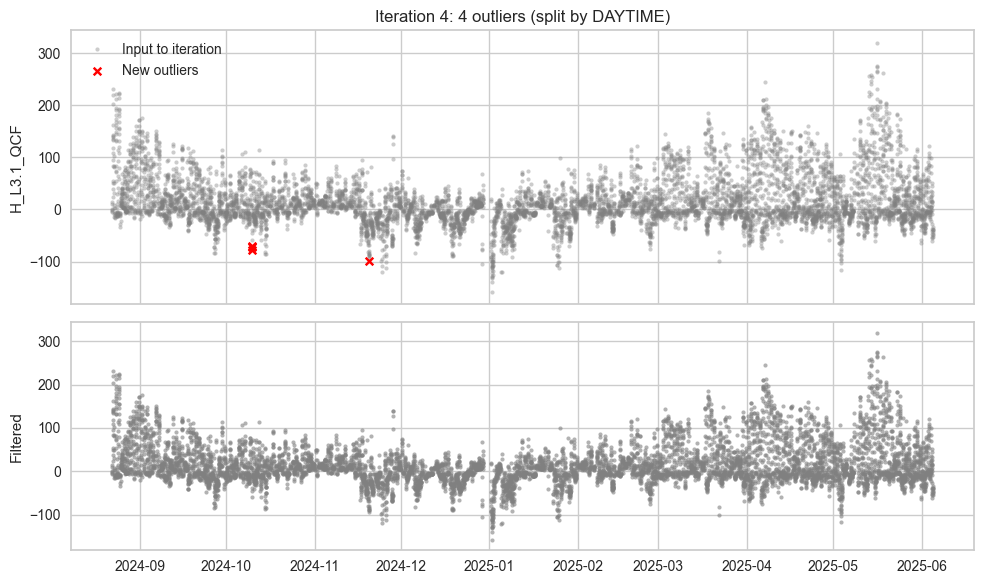


Iteration 5
HQRoll detected 1 new outliers.
Outliers this round: 1


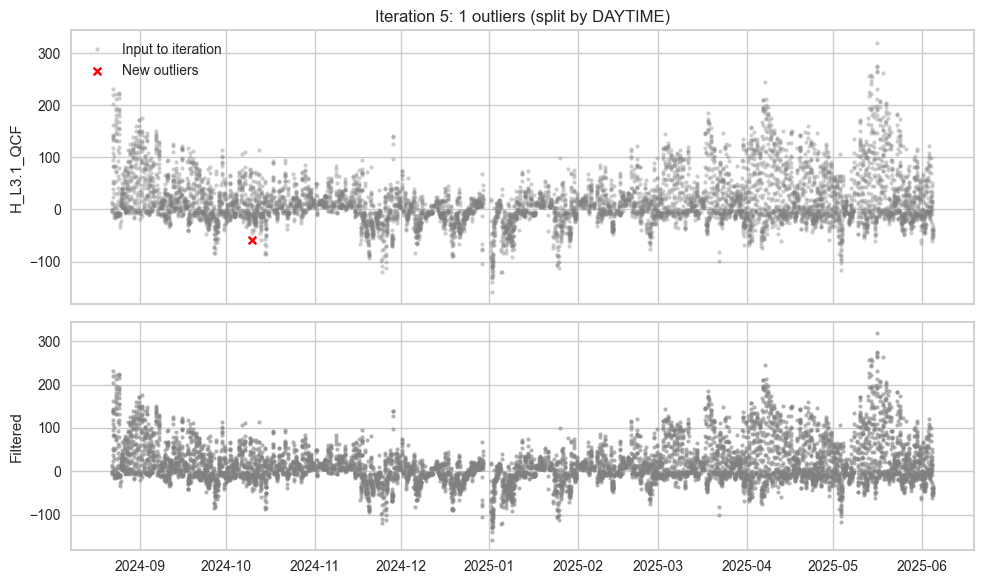

In [50]:
# --- Parameters
window = 48 * 3
threshold = 3
ustar_threshold = 0.1
max_iterations = 5

# --- Initialization
series = fpc._level32._series_hires_cleaned.copy()
total_flag = pd.Series(False, index=series.index)

dayflag = fpc.fpc_df['DAYTIME'].astype(int)  # 1=day, 0=night

for i in range(max_iterations):
    print(f"\nIteration {i+1}")

    # masks that don't depend on daytime
    qcf0_mask = fpc.fpc_df[f'{FLUXVAR}_L3.1_QCF0'].notna()
    ustar_mask = fpc.fpc_df['USTAR'] > ustar_threshold

    # we'll build flags for this iteration per group and combine
    flags_iter = pd.Series(False, index=series.index)

    # run HQRoll separately for DAYTIME==0 and DAYTIME==1
    for g in (0, 1):
        idx = dayflag.index[dayflag == g]           # positions for this group
        s_sub = series.loc[idx]
        hq_mask_sub = (qcf0_mask.loc[idx] & ustar_mask.loc[idx])

        # rolling stats only within the subgroup
        s_hq = s_sub.where(hq_mask_sub)
        rm = s_hq.rolling(window=window, center=True, min_periods=3).median()
        rs = s_hq.rolling(window=window, center=True, min_periods=3).std()

        valid = s_sub.notna() & rm.notna() & rs.notna()
        dev = (s_sub - rm).abs()
        flag_sub = (dev > threshold * rs) & valid

        flags_iter.loc[idx] = flag_sub

    n_flag = flags_iter.sum()
    print(f"HQRoll detected {n_flag} new outliers.")

    if n_flag == 0:
        break

    total_flag |= flags_iter

    outliers = series.where(flags_iter).dropna()
    print(f"Outliers this round: {outliers.shape[0]}")

    # update series for next iteration (remove newly-flagged points)
    series = series.where(~flags_iter)

    # (optional) plot
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                            gridspec_kw={'height_ratios': [1.2, 1]})
    axs[0].plot(series.index, series, 'o', ms=3, color='gray', alpha=0.4, label='Input to iteration')
    axs[0].scatter(outliers.index, outliers.values, color='red', s=30, marker='x', label='New outliers', zorder=3)
    axs[0].legend(loc='upper left')
    axs[0].set_ylabel(series.name)
    axs[0].set_title(f"Iteration {i+1}: {n_flag} outliers (split by DAYTIME)")

    axs[1].plot(series.index, series, 'o', ms=3, color='gray', alpha=0.6)
    axs[1].set_ylabel("Filtered")
    fig.tight_layout()
    plt.show()


In [51]:
# --- Store result
flagname = f"FLAG_L3.2_{fpc.level31.flux_corrected_col}_QCF_OUTLIER_HQROLL"
fpc.level32.flags[flagname] = total_flag
fpc._level32._series_hires_cleaned = fpc._level32._series_hires_cleaned.where(~total_flag)
flagname = f"FLAG_L3.2_{FLUXVAR}_L3.1_QCF_OUTLIER_HQROLL_TEST"
fpc.level32.flags[flagname] = total_flag.replace({True: 2.0, False: 0.0})
print(f"\nTotal outliers after {i+1} iterations: {total_flag.sum()} stored as {flagname}")


Total outliers after 5 iterations: 138 stored as FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL_TEST


</br>

</br>

## Outlier flag: **Hampel filter**, separate for daytime and nighttime
- Recommended filter
- Is slow compared to other filters:
    - tested with 1 year of 30MIN time resolution data and it needed approx. 43 seconds on a fast desktop computer

In [52]:
# from diive.pkgs.outlierdetection.hampel import Hampel
# help(Hampel)

In [53]:
# %%time
# WINDOW_LENGTH = 48 
# N_SIGMA_DT = 8
# N_SIGMA_NT = 6
# fpc.level32_flag_outliers_hampel_dtnt_test(window_length=WINDOW_LENGTH, n_sigma_dt=N_SIGMA_DT, n_sigma_nt=N_SIGMA_NT,
#                                            showplot=True, verbose=True, repeat=True)

In [54]:
#fpc.level32_addflag()

</br>

</br>

## Outlier flag: **z-score across all data**

In [55]:
# from diive.pkgs.outlierdetection.zscore import zScore
# help(zScore)

In [56]:
# THRES_ZSCORE = 6
# fpc.level32_flag_outliers_zscore_test(thres_zscore=THRES_ZSCORE, showplot=True, verbose=True, repeat=True)

In [57]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Hampel filter**
- Recommended filter
- Is slow compared to other filters:
    - tested with 1 year of 30MIN time resolution data and it needed approx. 33 seconds on a fast desktop computer
    - tested with 19 years of 30MIN time resolution data and it needed approx. 20 minutes on a fast desktop computer

In [58]:
# from diive.pkgs.outlierdetection.hampel import Hampel
# help(Hampel)

In [59]:
# WINDOW_LENGTH = 48 * 13
# N_SIGMA = 6
# %%time
# fpc.level32_flag_outliers_hampel_test(window_length=WINDOW_LENGTH, n_sigma=N_SIGMA, showplot=True, verbose=True, repeat=True)

In [60]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **z-score over all data**, separate for daytime and nighttime

In [61]:
# from diive.pkgs.outlierdetection.zscore import zScoreDaytimeNighttime
# help(zScoreDaytimeNighttime)

In [62]:
# THRES_ZSCORE = 5
# fpc.level32_flag_outliers_zscore_dtnt_test(thres_zscore=THRES_ZSCORE, showplot=True, verbose=True, repeat=True)

In [63]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Rolling z-score over all data**

In [64]:
# from diive.pkgs.outlierdetection.zscore import zScoreRolling
# help(zScoreRolling)

In [65]:
# THRES_ZSCORE = 5.5
# WINSIZE = 48 * 13
# fpc.level32_flag_outliers_zscore_rolling_test(winsize=WINSIZE, thres_zscore=THRES_ZSCORE, showplot=True, verbose=True, repeat=True)

In [66]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Local standard deviation**, with rolling median and *constant* standard deviation
- keep standard deviation constant by setting parameter `constant_sd=True`

In [67]:
# N_SD = 4.5
# WINSIZE = 48 * 9
# fpc.level32_flag_outliers_localsd_test(n_sd=N_SD, winsize=WINSIZE, constant_sd=True, showplot=True, verbose=True, repeat=True)

In [68]:
#fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Increments z-score**

In [69]:
# from diive.pkgs.outlierdetection.incremental import zScoreIncrements
# help(zScoreIncrements)

In [70]:
# THRES_ZSCORE = 4
# fpc.level32_flag_outliers_increments_zcore_test(thres_zscore=THRES_ZSCORE, showplot=True, verbose=True, repeat=True)

In [71]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Local outlier factor**, daytime/nighttime
- Test is run separately for daytime and nighttime data
- Description of local outlier factor: [here](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html)

In [72]:
# from diive.pkgs.outlierdetection.lof import LocalOutlierFactorDaytimeNighttime
# help(LocalOutlierFactorDaytimeNighttime)

In [73]:
# N_NEIGHBORS = None
# CONTAMINATION = None
# fpc.level32_flag_outliers_lof_dtnt_test(n_neighbors=N_NEIGHBORS, contamination=CONTAMINATION, showplot=True, verbose=True, repeat=False, n_jobs=-1)

In [74]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Local outlier factor**
- Test is run across all data
- Description of local outlier factor: [here](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html)

In [75]:
# from diive.pkgs.outlierdetection.lof import LocalOutlierFactorAllData
# help(LocalOutlierFactorAllData)

In [76]:
# N_NEIGHBORS = 24
# CONTAMINATION = None
# fpc.level32_flag_outliers_lof_test(n_neighbors=N_NEIGHBORS, contamination=CONTAMINATION, showplot=True, verbose=True, repeat=False, n_jobs=-1)

In [77]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Absolute limits**, separate for daytime and nighttime data

In [78]:
# from diive.pkgs.outlierdetection.absolutelimits import AbsoluteLimitsDaytimeNighttime
# help(AbsoluteLimitsDaytimeNighttime)

In [79]:
# MIN_DT = -50
# MAX_DT = 50
# MIN_NT = -25
# MAX_NT = 25
# fpc.level32_flag_outliers_abslim_dtnt_test(daytime_minmax=[MIN_DT, MAX_DT], nighttime_minmax=[MIN_NT, MAX_NT], showplot=True, verbose=True)

In [80]:
# fpc.level32_addflag()

</br>

</br>

## Outlier flag: **Trim nighttime flux data**

In [81]:
# from diive.pkgs.outlierdetection.trim import TrimLow
# help(TrimLow)

In [82]:
#fpc.level32_flag_outliers_trim_low_test(trim_nighttime=True, lower_limit=-5, showplot=True, verbose=True)

In [83]:
# fpc.level32_addflag()

</br>

</br>

## **Finalize Level-3.2**: Calculate overall quality flag (so far)

In [84]:
fpc.finalize_level32()

++Added new column FLAG_L3.2_H_L3.1_QCF_OUTLIER_ABSLIM_TEST.
++Added new column FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL.
++Added new column FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL_TEST.
++Added new column SUM_L3.2_H_L3.1_HARDFLAGS.
++Added new column SUM_L3.2_H_L3.1_SOFTFLAGS.
++Added new column SUM_L3.2_H_L3.1_FLAGS.
++Added new column FLAG_L3.2_H_L3.1_QCF.
++Added new column H_L3.1_L3.2_QCF.
++Added new column H_L3.1_L3.2_QCF0.


</br>

### Available `Level-3.2` variables
- This shows all available Level-3.2 variables for this flux

In [85]:
[x for x in fpc.fpc_df.columns if 'L3.2' in x]

['FLAG_L3.2_H_L3.1_QCF_OUTLIER_ABSLIM_TEST',
 'FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL',
 'FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL_TEST',
 'SUM_L3.2_H_L3.1_HARDFLAGS',
 'SUM_L3.2_H_L3.1_SOFTFLAGS',
 'SUM_L3.2_H_L3.1_FLAGS',
 'FLAG_L3.2_H_L3.1_QCF',
 'H_L3.1_L3.2_QCF',
 'H_L3.1_L3.2_QCF0']

</br>

### Plot filtered flux after Level-3.2
In the four panels, from left to right:
- flux after Level-3.1, before outlier removal
- flux after Level-3.2, after outlier removal
- sum of the individual test flags
- overall flag `QCF` (quality control flag), where `0`=best quality, `1`=medium quality, `2`=bad quality  

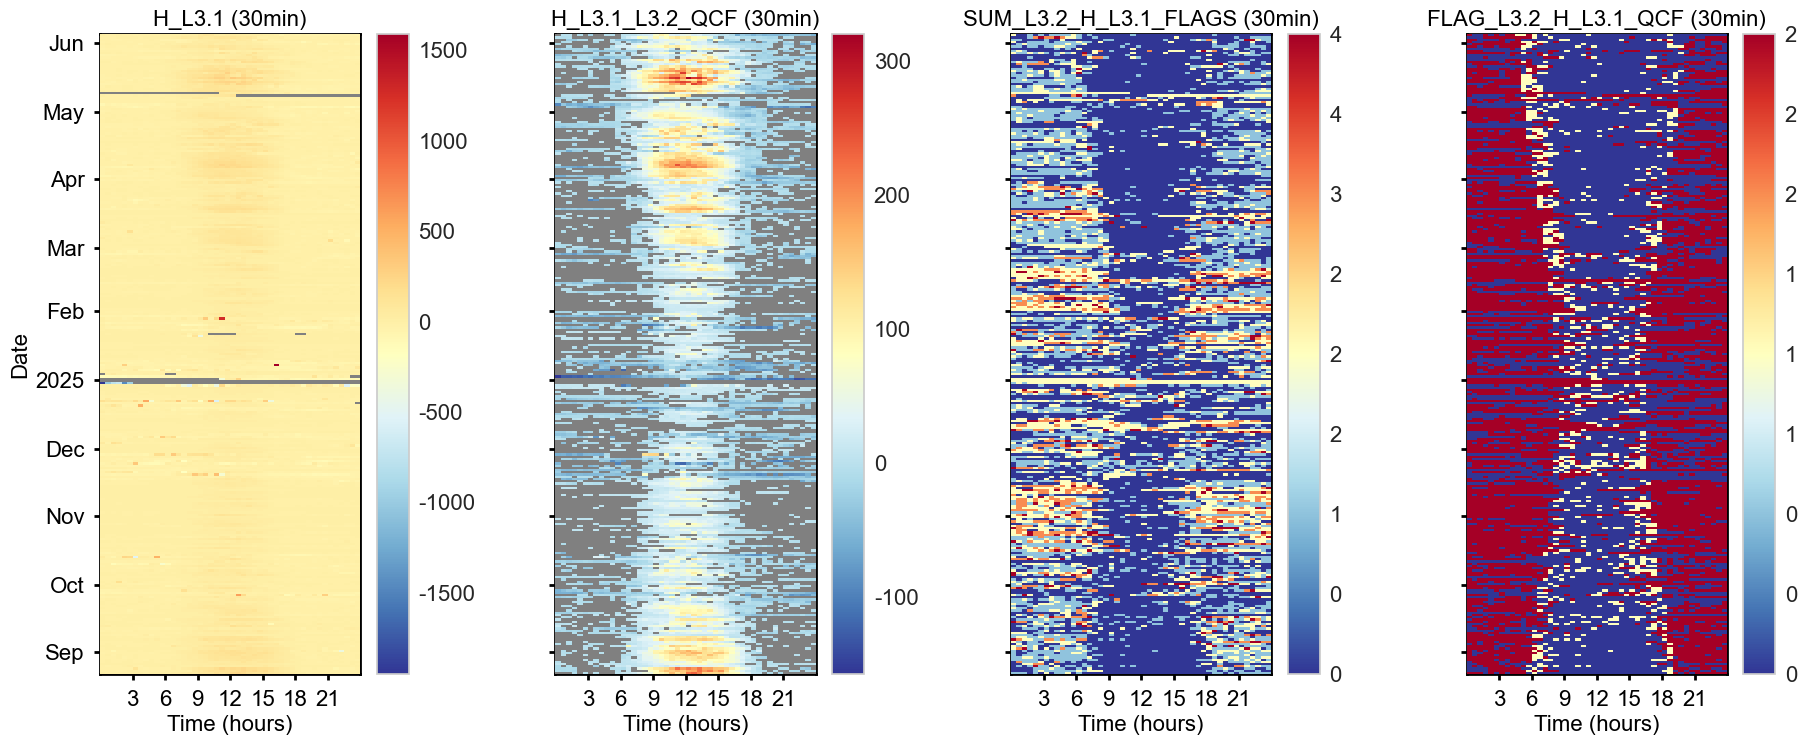

In [86]:
fpc.level32_qcf.showplot_qcf_heatmaps()

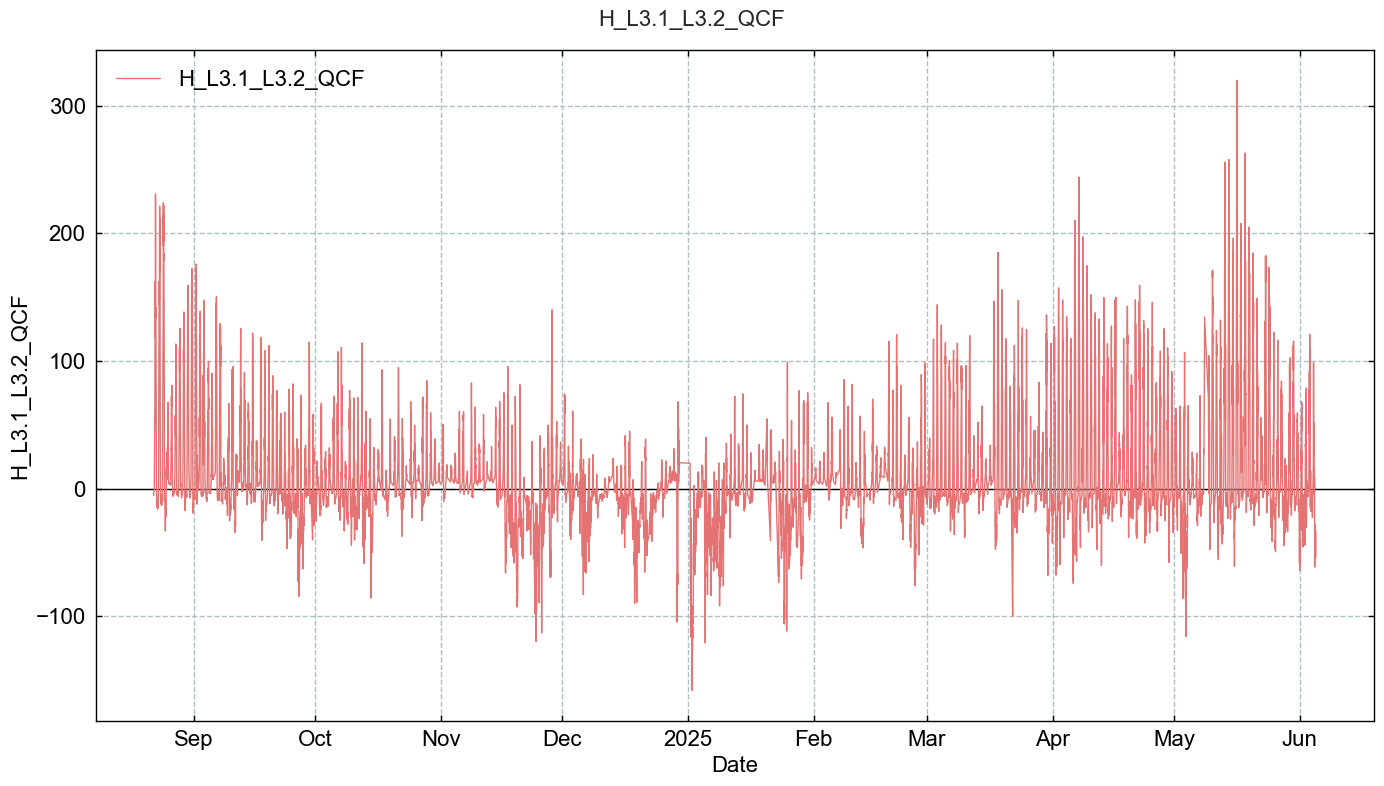

In [87]:
TimeSeries(series=fpc.filteredseries).plot()
TimeSeries(series=fpc.filteredseries).plot_interactive()

In [88]:
# fpc.level32_qcf.showplot_qcf_timeseries()

</br>

### Reports

In [89]:
fpc.level32_qcf.report_qcf_evolution()



QCF FLAG EVOLUTION
This output shows the evolution of the QCF overall quality flag
when test flags are applied sequentially to the variable H_L3.1.

Number of H_L3.1 records before QC: 13606
+++ FLAG_L2_H_MISSING_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 13606 (100.00%) / flag 1: 0 (0.00%) / flag 2: 0 (0.00%)
+++ FLAG_L2_H_SSITC_TEST rejected 4193 values (+30.82%)      TOTALS: flag 0: 8302 (61.02%) / flag 1: 1111 (8.17%) / flag 2: 4193 (30.82%)
+++ FLAG_L2_H_COMPLETENESS_TEST rejected 3 values (+0.02%)      TOTALS: flag 0: 8299 (61.00%) / flag 1: 1111 (8.17%) / flag 2: 4196 (30.84%)


+++ FLAG_L2_H_SCF_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 8299 (61.00%) / flag 1: 1111 (8.17%) / flag 2: 4196 (30.84%)
+++ FLAG_L2_H_T_SONIC_VM97_SPIKE_HF_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 8299 (61.00%) / flag 1: 1111 (8.17%) / flag 2: 4196 (30.84%)
+++ FLAG_L2_H_T_SONIC_VM97_AMPLITUDE_RESOLUTION_HF_TEST rejected 1396 values (+10.26%)      TOTALS: flag 0: 7094 (52.14%) / flag 1: 920 (6.76%) / flag 2: 5592 (41.10%)
+++ FLAG_L2_H_T_SONIC_VM97_DROPOUT_TEST rejected 0 values (+0.00%)      TOTALS: flag 0: 7094 (52.14%) / flag 1: 920 (6.76%) / flag 2: 5592 (41.10%)


+++ FLAG_L3.2_H_L3.1_QCF_OUTLIER_ABSLIM_TEST rejected 9 values (+0.07%)      TOTALS: flag 0: 7089 (52.10%) / flag 1: 916 (6.73%) / flag 2: 5601 (41.17%)
+++ FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL_TEST rejected 138 values (+1.01%)      TOTALS: flag 0: 6971 (51.23%) / flag 1: 896 (6.59%) / flag 2: 5739 (42.18%)

In total, 5739 (42.18%) of the available records were rejected in this step.
INFO Rejected DAYTIME records where QCF flag >= 2
INFO Rejected NIGHTTIME records where QCF flag >= 1


In [90]:
fpc.level32_qcf.report_qcf_series()



SUMMARY: FLAG_L3.2_H_L3.1_QCF, QCF FLAG FOR H_L3.1
Between 2024-08-22 00:15 and 2025-06-04 23:45 ...
    Total flux records BEFORE quality checks: 13606 (98.77% of potential)
    Available flux records AFTER quality checks: 7867 (57.82% of total)
    Rejected flux records: 5739 (42.18% of total)
    Potential flux records: 13776
    Potential flux records missed: 170 (1.23% of potential)



In [91]:
fpc.level32_qcf.report_qcf_flags()


REPORT: FLAGS INCL. MISSING VALUES
Stats with missing values in the dataset
FLAG_L2_H_MISSING_TEST:
    OVERALL flag 0.0: 13606 values (98.77%)  
    OVERALL flag 2.0: 170 values (1.23%)  
    OVERALL flag missing: 0 values (0.00%)  

    DAYTIME flag 0.0: 6200 values (98.92%)  
    DAYTIME flag 2.0: 68 values (1.08%)  
    DAYTIME flag missing: 0 values (0.00%)  

    NIGHTTIME flag 0.0: 7406 values (98.64%)  
    NIGHTTIME flag 2.0: 102 values (1.36%)  
    NIGHTTIME flag missing: 0 values (0.00%)  

FLAG_L2_H_SSITC_TEST:
    OVERALL flag 0.0: 8302 values (60.26%)  
    OVERALL flag 1.0: 4205 values (30.52%)  
    OVERALL flag 2.0: 1099 values (7.98%)  
    OVERALL flag missing: 170 values (1.23%)  

    DAYTIME flag 0.0: 4783 values (76.31%)  
    DAYTIME flag 1.0: 1111 values (17.72%)  
    DAYTIME flag 2.0: 306 values (4.88%)  
    DAYTIME flag missing: 68 values (1.08%)  

    NIGHTTIME flag 0.0: 3519 values (46.87%)  
    NIGHTTIME flag 1.0: 3094 values (41.21%)  
    NIGHTTIME

    NIGHTTIME flag 0.0: 5732 values (76.35%)  
    NIGHTTIME flag 2.0: 1674 values (22.30%)  
    NIGHTTIME flag missing: 102 values (1.36%)  

FLAG_L2_H_T_SONIC_VM97_DROPOUT_TEST:
    OVERALL flag 0.0: 13606 values (98.77%)  
    OVERALL flag missing: 170 values (1.23%)  

    DAYTIME flag 0.0: 6200 values (98.92%)  
    DAYTIME flag missing: 68 values (1.08%)  

    NIGHTTIME flag 0.0: 7406 values (98.64%)  
    NIGHTTIME flag missing: 102 values (1.36%)  

FLAG_L2_H_QCF:
    OVERALL flag 0.0: 7094 values (51.50%)  
    OVERALL flag 1.0: 920 values (6.68%)  
    OVERALL flag 2.0: 5762 values (41.83%)  
    OVERALL flag missing: 0 values (0.00%)  

    DAYTIME flag 0.0: 4449 values (70.98%)  
    DAYTIME flag 1.0: 920 values (14.68%)  
    DAYTIME flag 2.0: 899 values (14.34%)  
    DAYTIME flag missing: 0 values (0.00%)  

    NIGHTTIME flag 0.0: 2645 values (35.23%)  
    NIGHTTIME flag 2.0: 4863 values (64.77%)  
    NIGHTTIME flag missing: 0 values (0.00%)  

FLAG_L3.2_H_L3.1_QCF_

    OVERALL flag 0.0: 13606 values (100.00%)  
    OVERALL flag missing: 0 values (0.00%)  



    DAYTIME flag 0.0: 6200 values (100.00%)  
    DAYTIME flag missing: 0 values (0.00%)  

    NIGHTTIME flag 0.0: 7406 values (100.00%)  
    NIGHTTIME flag missing: 0 values (0.00%)  

FLAG_L2_H_SSITC_TEST:
    OVERALL flag 0.0: 8302 values (61.02%)  
    OVERALL flag 1.0: 4205 values (30.91%)  
    OVERALL flag 2.0: 1099 values (8.08%)  
    OVERALL flag missing: 0 values (0.00%)  

    DAYTIME flag 0.0: 4783 values (77.15%)  
    DAYTIME flag 1.0: 1111 values (17.92%)  
    DAYTIME flag 2.0: 306 values (4.94%)  
    DAYTIME flag missing: 0 values (0.00%)  

    NIGHTTIME flag 0.0: 3519 values (47.52%)  
    NIGHTTIME flag 1.0: 3094 values (41.78%)  
    NIGHTTIME flag 2.0: 793 values (10.71%)  
    NIGHTTIME flag missing: 0 values (0.00%)  

FLAG_L2_H_COMPLETENESS_TEST:
    OVERALL flag 0.0: 13599 values (99.95%)  
    OVERALL flag 1.0: 4 values (0.03%)  
    OVERALL flag 2.0: 3 values (0.02%)  
    OVERALL flag missing: 0 values (0.00%)  

    DAYTIME flag 0.0: 6198 values (99.97

    OVERALL flag 0.0: 7094 values (52.14%)  
    OVERALL flag 1.0: 920 values (6.76%)  
    OVERALL flag 2.0: 5592 values (41.10%)  
    OVERALL flag missing: 0 values (0.00%)  

    DAYTIME flag 0.0: 4449 values (71.76%)  
    DAYTIME flag 1.0: 920 values (14.84%)  
    DAYTIME flag 2.0: 831 values (13.40%)  
    DAYTIME flag missing: 0 values (0.00%)  

    NIGHTTIME flag 0.0: 2645 values (35.71%)  
    NIGHTTIME flag 2.0: 4761 values (64.29%)  
    NIGHTTIME flag missing: 0 values (0.00%)  

FLAG_L3.2_H_L3.1_QCF_OUTLIER_ABSLIM_TEST:
    OVERALL flag 0.0: 13597 values (99.93%)  
    OVERALL flag 2.0: 9 values (0.07%)  
    OVERALL flag missing: 0 values (0.00%)  

    DAYTIME flag 0.0: 6196 values (99.94%)  
    DAYTIME flag 2.0: 4 values (0.06%)  
    DAYTIME flag missing: 0 values (0.00%)  

    NIGHTTIME flag 0.0: 7401 values (99.93%)  
    NIGHTTIME flag 2.0: 5 values (0.07%)  
    NIGHTTIME flag missing: 0 values (0.00%)  

FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL_TEST:
    OVERALL f

</br>

# **Save Level-3.2 results to file**

In [92]:
results_df = fpc.get_data()
filename = f"43.1_FluxProcessingChain_L3.2_{FLUXVAR}"
save_parquet(data=results_df, filename=filename)

NEW VARIABLES FROM FLUX PROCESSING CHAIN:
++ FLAG_L2_H_MISSING_TEST
++ FLAG_L2_H_SSITC_TEST
++ FLAG_L2_H_COMPLETENESS_TEST
++ FLAG_L2_H_SCF_TEST
++ FLAG_L2_H_T_SONIC_VM97_SPIKE_HF_TEST
++ FLAG_L2_H_T_SONIC_VM97_AMPLITUDE_RESOLUTION_HF_TEST
++ FLAG_L2_H_T_SONIC_VM97_DROPOUT_TEST
++ SUM_L2_H_HARDFLAGS
++ SUM_L2_H_SOFTFLAGS
++ SUM_L2_H_FLAGS
++ FLAG_L2_H_QCF
++ H_L2_QCF
++ H_L2_QCF0
++ SH_SINGLE_gfRMED_L3.1
++ FLAG_SH_SINGLE_gfRMED_L3.1_ISFILLED
++ H_L3.1
++ H_L3.1_QCF
++ H_L3.1_QCF0
++ FLAG_L3.2_H_L3.1_QCF_OUTLIER_ABSLIM_TEST
++ FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL
++ FLAG_L3.2_H_L3.1_QCF_OUTLIER_HQROLL_TEST
++ SUM_L3.2_H_L3.1_HARDFLAGS
++ SUM_L3.2_H_L3.1_SOFTFLAGS
++ SUM_L3.2_H_L3.1_FLAGS
++ FLAG_L3.2_H_L3.1_QCF
++ H_L3.1_L3.2_QCF
++ H_L3.1_L3.2_QCF0
No variables in input data were overwritten, only new variables added.


Saved file 43.1_FluxProcessingChain_L3.2_H.parquet (0.999 seconds).


'43.1_FluxProcessingChain_L3.2_H.parquet'

---

# **End of notebook**

---

Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [93]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-10-06 15:23:54
